In [1]:
import torch
from diffusion import Diffusion
from v1_sliding_diffusion import SlidingDiffusion
from v1_normal_diffusion import NormalDiffusion
from v1_model import ContinuousMotionModel
from utils.debugger import Debugger
from v1_training_loop import train
from v1_sliding_diffusion import Diffusion
from pose_encoder.advanced_pose_encoder import AdvancedPoseEncoder
from torch.utils.data import DataLoader
from dataset.dataset import *
import wandb
import utils.utils as utils

wandb.login()

device = utils.get_device()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: pefu (pefu-it-university-of-copenhagen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


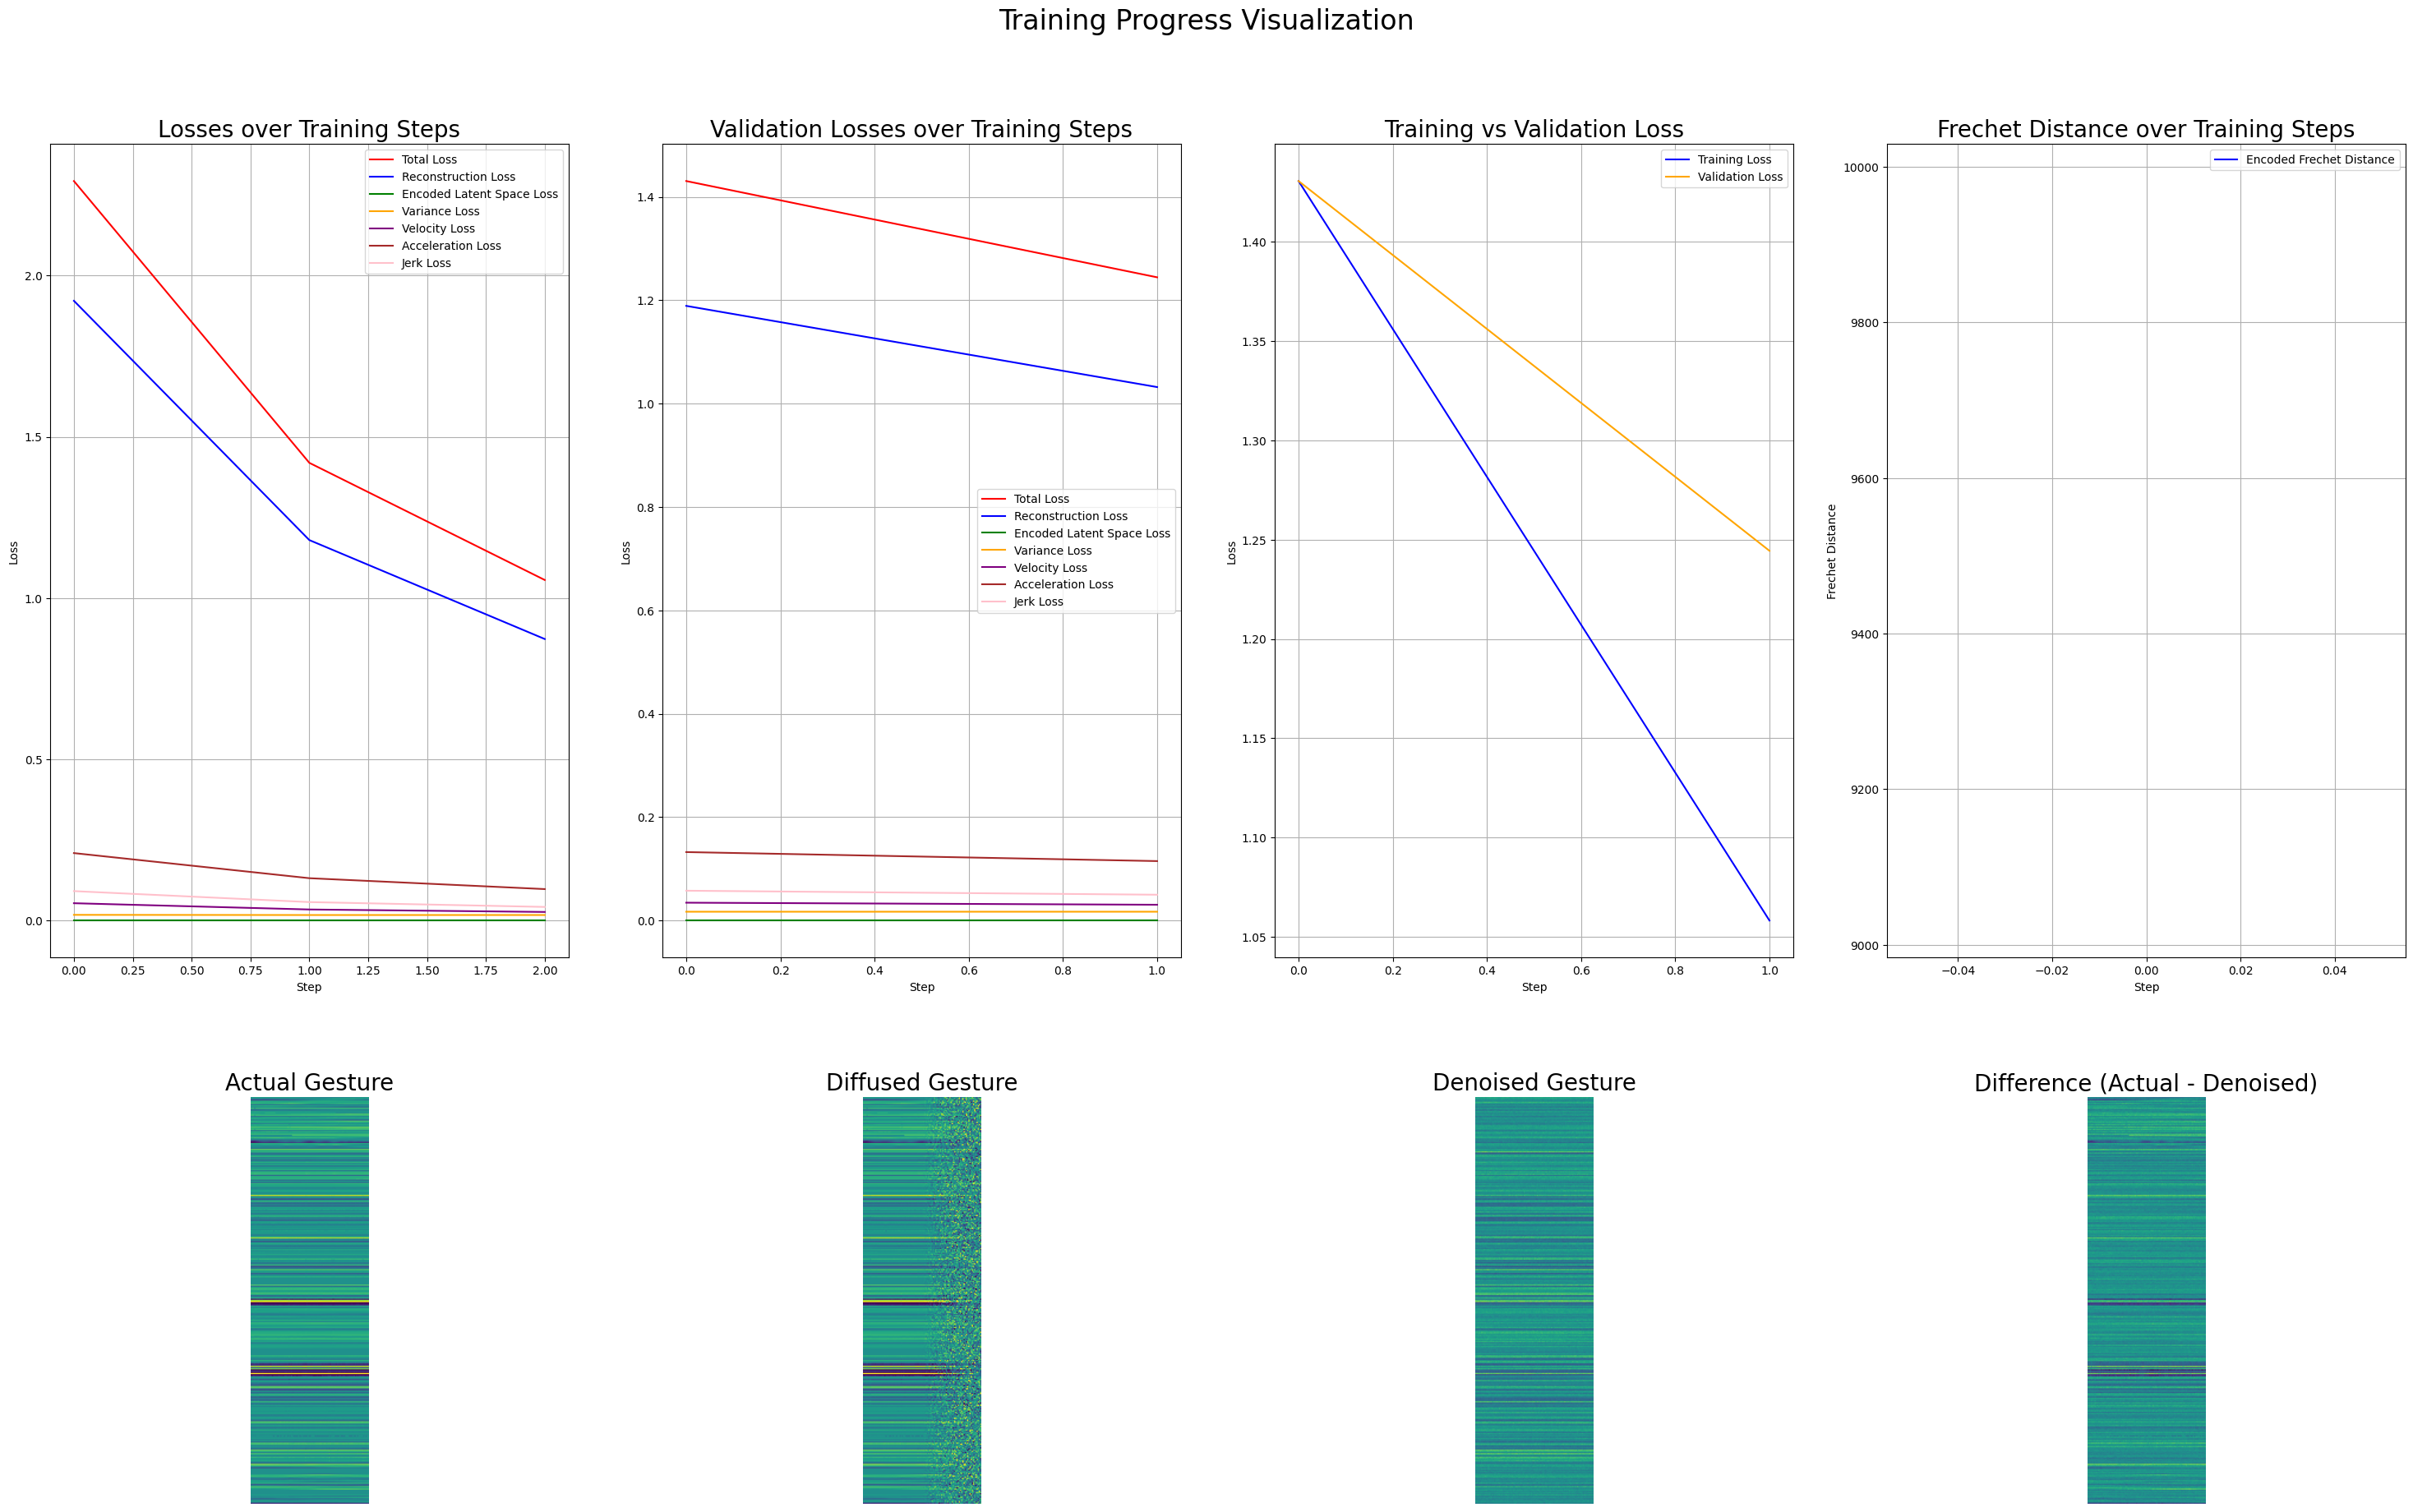

Epoch 3/1000:  13%|█▎        | 13/100 [00:01<00:11,  7.54it/s, Training loss=0.9538983106613159, Last epoch loss=1.0582203143835067, Frechet distance=9506.543659614948]


KeyboardInterrupt: 

In [2]:
train(
    experiment_collection_name = "first_tests",
    upload_model_check_point = False, # should upload the model checkpoint to wandb
    model_checkpoint_dir = "v1_models",
    model = ContinuousMotionModel(
        diffusion = SlidingDiffusion(
            num_clean_frames = 50,
            num_denoise_frames = 50,
            num_noise_frames = 0,
            num_timestep_stackings = 1,
            noise_schedule = Diffusion.linear_schedule(0.00015, 0.15),
            device = device
        ),
        # diffusion = NormalDiffusion(
        #     num_timesteps = 100,
        #     sequence_length = 100,
        #     noise_schedule = Diffusion.linear_schedule(0.00015, 0.075),
        #     device = device
        # ),
        pose_encoder = None, # AdvancedPoseEncoder.load_from_checkpoint("advanced_pose_encoder_ik_pca_64", device),
        number_of_styles = 17,
        gesture_length = 100,
        seed_length = 8,
        audio_features_per_frame = 37,
        pose_features_per_frame = 345,
        condition_mask_probabilty = 0.1,
        number_of_attention_heads = 8,
        predict_full_duration = True,
        reinject_seed_style_full_t = False,
        reinject_seed_style_frame_t = True,
        num_frames_without_audio = 15,
        debugger = Debugger(
            on = False, 
            keys_for_printing_while_running = ["ALL"]
        ),
        device = device
    ),
    device = device,
    training_loader = DataLoader(
            GPUDataset(
                consolidated_file = "dataset/genea2023_dataset/trn/main-agent/consolidated.npz",
                seq_length = 100,
                seed_length = 8,
                batch_size = 256,
                epoch_length = 100,
                loading_encoded_data = False,
                include_vel_acc_features = False,
                device = device
            ),
            batch_size = 1,
            num_workers = 0,
            pin_memory = False  
        ),
    val_loader = DataLoader(
            GPUDataset(
                consolidated_file = "dataset/genea2023_dataset/val/main-agent/consolidated.npz",
                seq_length = 100,
                seed_length = 8,
                batch_size = 64,
                epoch_length = 30,
                loading_encoded_data = False,
                include_vel_acc_features = False,
                device = device
            ),
            batch_size = 1,
            num_workers = 0,
            pin_memory = False
        ),
    num_epochs = 1000,
    learning_rate = 0.000025,
    reconstruction_loss_weight = 4.0,
    variance_loss_weight = 0.1,
    velocity_loss_weight = 1.0,
    acceleration_loss_weight = 1.5,
    jerk_loss_weight= 0.2,
    latent_space_loss_weight = 0.0,
    # category_weighting = {
    #     'fingers': 0.1,
    #     'arms': 2.0,
    #     'legs': 1.0,
    #     'spine': 2.0,
    #     'head': 1.0,
    #     'root': 2.0
    # },
    # category_weighting = {
    #     'left_arm_ik': 2.0,
    #     'right_arm_ik': 2.0,
    #     'left_leg_ik': 2.0,
    #     'right_leg_ik': 2.0,
    # },
    # frame_weighting_segments_info = [
    #     (0.1, 0.2, 25),
    #     (0.2, 0.4, 40),
    #     (0.4, 1.0, 50),
    #     (1.0, 1.0, 55),
    #     (1.0, 0.85, 80),
    #     (0.85, 0.6, 100)
    # ],
    visualize_step = 100,
    num_fgd_samples = 2048,
    # continue_from_checkpoint="latest"
)